# 🎓 Практический семинар: Линейная регрессия от интуиции до краш-тестов

**Цель занятия:**
1. Понять физический и геометрический смысл Метода Наименьших Квадратов (МНК).
2. Научиться обучать и интерпретировать модель в `scikit-learn`.
3. Провести «краш-тесты» модели: выбросы, нелинейность, мультиколлинеарность.
4. Освоить диагностику через анализ остатков (Residual Analysis).

## 1. Импорт библиотек и настройка окружения

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression, Ridge, HuberRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import PolynomialFeatures

# Настройки оформления графиков
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (9, 5)
plt.rcParams["font.size"] = 11

## 2. Интуиция и генерация данных

Смоделируем задачу: **Связь времени подготовки (часы) и балла за экзамен (0–100)**.

Истинная зависимость в природе:
$$\text{Score} = 15 + 5.5 \times \text{Hours} + \epsilon, \quad \epsilon \sim \mathcal{N}(0, 6^2)$$

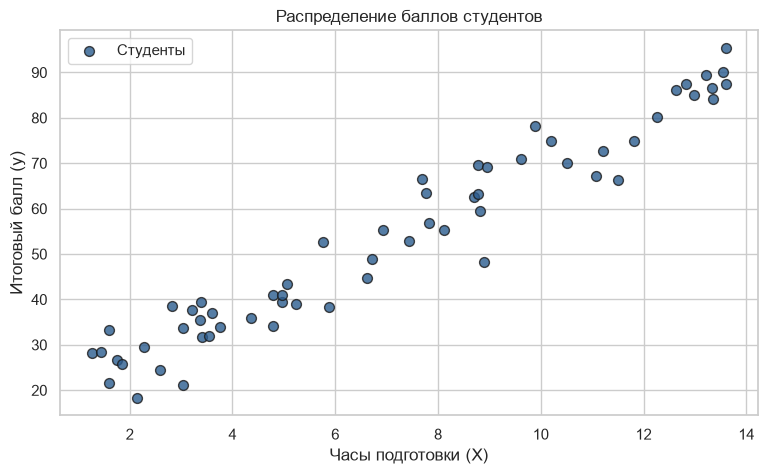

In [2]:
np.random.seed(42)
n_samples = 60

# Часы подготовки от 1 до 14
hours = np.random.uniform(1.0, 14.0, n_samples)
# Шум и балл
noise = np.random.normal(0, 6.0, n_samples)
scores = 15 + 5.5 * hours + noise
# Ограничим балл максимум 100
scores = np.clip(scores, 0, 100)

X = hours.reshape(-1, 1)
y = scores

# Визуализация
plt.scatter(X, y, color='#2b5c8f', s=50, alpha=0.8, edgecolors='k', label='Студенты')
plt.xlabel('Часы подготовки (X)')
plt.ylabel('Итоговый балл (y)')
plt.title('Распределение баллов студентов')
plt.legend()
plt.show()

## 3. Обучение модели и интерпретация коэффициентов

Уравнение модели:
$$\hat{y} = w_0 + w_1 x$$

* $w_0$ (`intercept_`) — базовый балл при нулевой подготовке.
* $w_1$ (`coef_[0]`) — сколько баллов в среднем добавляет **1 час** подготовки.

🔹 Свободный член (w0 / Intercept): 15.70
🔹 Наклон прямой (w1 / Slope):     5.33
🔹 Коэффициент детерминации (R²):  0.940
🔹 Средняя ошибка (MAE):           4.19 балла


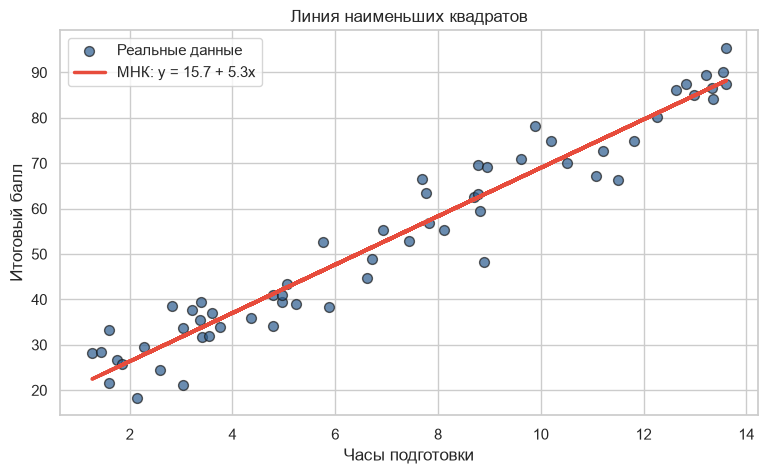

In [3]:
# Создаем и обучаем модель МНК
model = LinearRegression()
model.fit(X, y)

y_pred = model.predict(X)

print(f"🔹 Свободный член (w0 / Intercept): {model.intercept_:.2f}")
print(f"🔹 Наклон прямой (w1 / Slope):     {model.coef_[0]:.2f}")
print(f"🔹 Коэффициент детерминации (R²):  {r2_score(y, y_pred):.3f}")
print(f"🔹 Средняя ошибка (MAE):           {mean_absolute_error(y, y_pred):.2f} балла")

# График с линией регрессии
plt.scatter(X, y, color='#2b5c8f', s=50, alpha=0.7, edgecolors='k', label='Реальные данные')
plt.plot(X, y_pred, color='#e74c3c', linewidth=2.5, label=f'МНК: y = {model.intercept_:.1f} + {model.coef_[0]:.1f}x')
plt.xlabel('Часы подготовки')
plt.ylabel('Итоговый балл')
plt.title('Линия наименьших квадратов')
plt.legend()
plt.show()

## 4. Краш-тест 1: Эффект выброса (Outlier Sensitivity)

Что произойдет, если в группу попадет один студент, который учился **1 час**, но набрал **98 баллов** (списал или олимпиадник)?

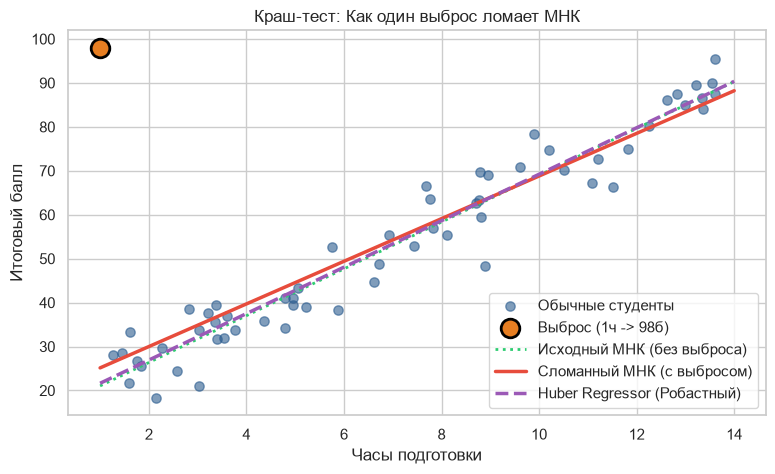

In [4]:
# Добавляем экстремальный выброс
X_outlier = np.vstack([X, [[1.0]]])
y_outlier = np.append(y, 98.0)

# Обучаем обычный МНК
model_broken = LinearRegression()
model_broken.fit(X_outlier, y_outlier)
y_pred_broken = model_broken.predict(X_outlier)

# Обучаем робастную регрессию Хьюбера
model_huber = HuberRegressor()
model_huber.fit(X_outlier, y_outlier)
y_pred_huber = model_huber.predict(X_outlier)

plt.scatter(X, y, color='#2b5c8f', s=45, alpha=0.6, label='Обычные студенты')
plt.scatter([1.0], [98.0], color='#e67e22', s=180, edgecolors='black', linewidth=2, label='Выброс (1ч -> 98б)')

x_line = np.linspace(1, 14, 100).reshape(-1, 1)
plt.plot(x_line, model.predict(x_line), color='#2ecc71', linestyle=':', linewidth=2, label='Исходный МНК (без выброса)')
plt.plot(x_line, model_broken.predict(x_line), color='#e74c3c', linewidth=2.5, label='Сломанный МНК (с выбросом)')
plt.plot(x_line, model_huber.predict(x_line), color='#9b59b6', linestyle='--', linewidth=2.5, label='Huber Regressor (Робастный)')

plt.xlabel('Часы подготовки')
plt.ylabel('Итоговый балл')
plt.title('Краш-тест: Как один выброс ломает МНК')
plt.legend()
plt.show()

## 5. Краш-тест 2: Мультиколлинеарность (Взрыв весов)

Добавим в модель признак «Время в минутах» ($x_2 = 60 \cdot x_1 + noise$).
Посмотрим, как веса теряют физический смысл без регуляризации.

In [5]:
# Создаем почти идеально скоррелированный признак
minutes = hours * 60 + np.random.normal(0, 0.5, size=n_samples)
X_multi = np.column_stack([hours, minutes])

# Обычный МНК
lr_multi = LinearRegression()
lr_multi.fit(X_multi, y)

# Ridge (L2-регуляризация)
ridge_multi = Ridge(alpha=100.0)
ridge_multi.fit(X_multi, y)

df_weights = pd.DataFrame({
    'Признак': ['Часы (X1)', 'Минуты (X2)'],
    'Вес в LinearRegression (МНК)': lr_multi.coef_,
    'Вес в Ridge (с L2-штрафом)': ridge_multi.coef_
})

display(df_weights)
print("Корреляция между признаками:", np.corrcoef(hours, minutes)[0, 1])

,Признак,Вес в LinearRegression (МНК),Вес в Ridge (с L2-штрафом)
0,Часы (X1),-137.037650,-0.004021
1,Минуты (X2),2.372522,0.088871


Корреляция между признаками: 0.9999978416849508


## 6. Диагностика: Анализ остатков (Residual Analysis)

Правильные остатки должны:
1. Быть центрированы около нуля.
2. Иметь одинаковый разброс (гомоскедастичность).
3. Не иметь выраженного тренда (бабочки, дуги, воронки).

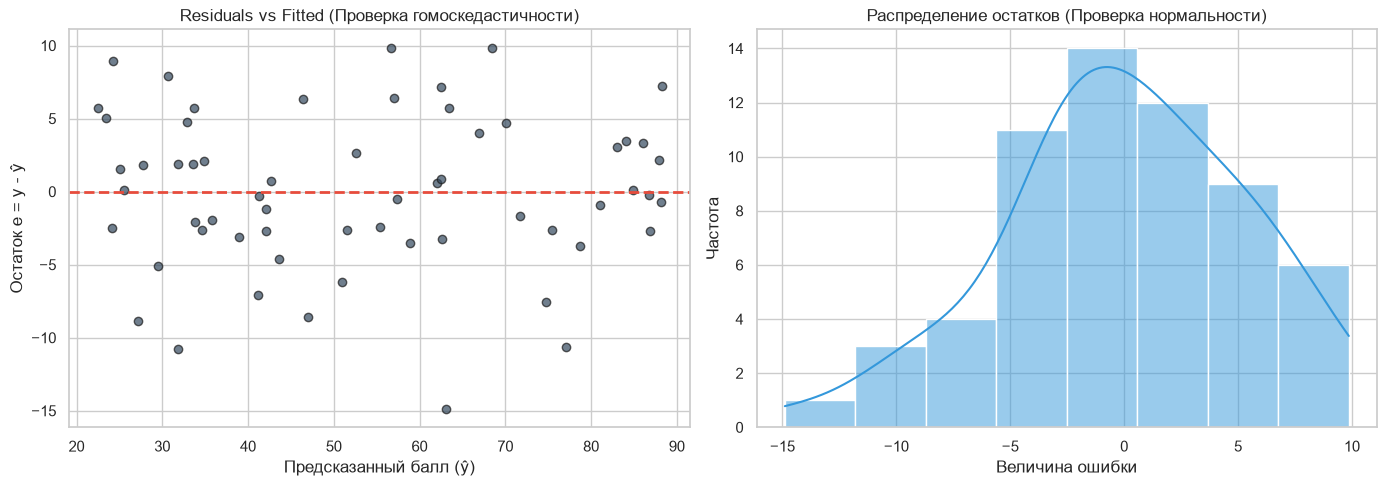

In [6]:
residuals = y - y_pred

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# График остатков vs Предсказания
axes[0].scatter(y_pred, residuals, color='#34495e', alpha=0.7, edgecolors='k')
axes[0].axhline(0, color='#e74c3c', linestyle='--', linewidth=2)
axes[0].set_xlabel('Предсказанный балл (ŷ)')
axes[0].set_ylabel('Остаток e = y - ŷ')
axes[0].set_title('Residuals vs Fitted (Проверка гомоскедастичности)')

# Гистограмма распределения ошибок
sns.histplot(residuals, kde=True, ax=axes[1], color='#3498db')
axes[1].set_xlabel('Величина ошибки')
axes[1].set_ylabel('Частота')
axes[1].set_title('Распределение остатков (Проверка нормальности)')

plt.tight_layout()
plt.show()

## 7. Практическое задание для студентов

**Задача:**
1. Сгенерируйте нелинейные данные (например, эффект усталости от слишком долгих часов учебы: $y = 10 + 12x - 0.5x^2$).
2. Обучите линейную регрессию и постройте график остатков. Заметьте, какую форму («дугу») образуют остатки.
3. Исправьте модель с помощью `PolynomialFeatures(degree=2)`.

In [7]:
# --- Место для решения студентов ---
# 1. Данные
x_poly = np.linspace(1, 15, 60)
y_poly = 10 + 12 * x_poly - 0.5 * (x_poly ** 2) + np.random.normal(0, 4, 60)
X_p = x_poly.reshape(-1, 1)

# 2. Попробуйте обучить LinearRegression напрямую vs с добавлением PolynomialFeatures
# Ваш код здесь...